# Линейная бинарная классификация через SGD: три функции потерь

Обучаю линейный классификатор $a(x) = \mathrm{sign}\,(w^{\top} x)$ стохастическим
градиентным спуском и сравниваю три функции потерь от отступа $M = (w^{\top} x)\, y$:

- сигмоидная: $L(M) = \dfrac{2}{1 + e^{M}}$ — ограниченная, почти не штрафует за
  большие положительные отступы;
- экспоненциальная: $L(M) = e^{-M}$ — агрессивно наказывает за ошибки;
- логарифмическая: $L(M) = \log_2(1 + e^{-M})$ — середина между ними, по сути
  логистическая регрессия.

Всё пишется на чистом numpy, включая метрики (accuracy, precision, recall, F1,
матрица ошибок).


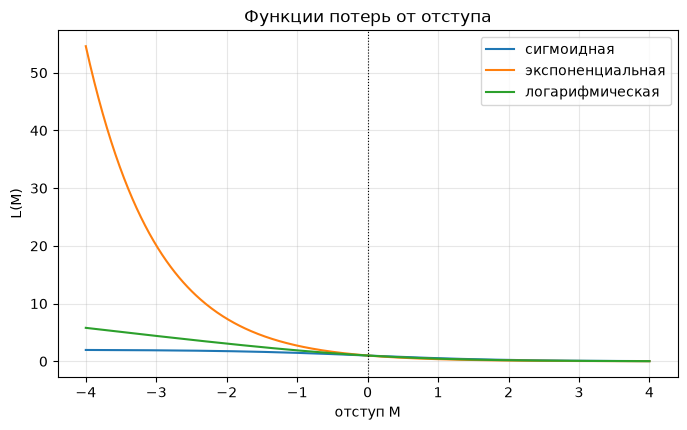

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# посмотрим на форму трёх функций потерь
M = np.linspace(-4, 4, 400)

plt.figure(figsize=(8, 4.5))
plt.plot(M, 2 / (1 + np.exp(M)), label="сигмоидная")
plt.plot(M, np.exp(-M), label="экспоненциальная")
plt.plot(M, np.log2(1 + np.exp(-M)), label="логарифмическая")
plt.axvline(0, color="black", lw=0.8, ls=":")
plt.xlabel("отступ M")
plt.ylabel("L(M)")
plt.title("Функции потерь от отступа")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


При $M < 0$ объект классифицирован неверно, и все три функции там растут,
но с разной скоростью. Экспонента штрафует жёстче всех, сигмоидная выходит на
плато и потому устойчивее к выбросам.

## 1. Сигмоидная функция потерь, мини-батч SGD

Данные — два класса цветков по длине и ширине лепестка (100 объектов).
Обучение: 500 итераций, мини-батч $K = 10$, свои шаги $\eta$ для каждого веса.


In [2]:
data_x = [(5.8, 1.2), (5.6, 1.5), (6.5, 1.5), (6.1, 1.3), (6.4, 1.3), (7.7, 2.0), (6.0, 1.8), (5.6, 1.3), (6.0, 1.6), (5.8, 1.9), (5.7, 2.0), (6.3, 1.5), (6.2, 1.8), (7.7, 2.3), (5.8, 1.2), (6.3, 1.8), (6.0, 1.0), (6.2, 1.3), (5.7, 1.3), (6.3, 1.9), (6.7, 2.5), (5.5, 1.2), (4.9, 1.0), (6.1, 1.4), (6.0, 1.6), (7.2, 2.5), (7.3, 1.8), (6.6, 1.4), (5.6, 2.0), (5.5, 1.0), (6.4, 2.2), (5.6, 1.3), (6.6, 1.3), (6.9, 2.1), (6.8, 2.1), (5.7, 1.3), (7.0, 1.4), (6.1, 1.4), (6.1, 1.8), (6.7, 1.7), (6.0, 1.5), (6.5, 1.8), (6.4, 1.5), (6.9, 1.5), (5.6, 1.3), (6.7, 1.4), (5.8, 1.9), (6.3, 1.3), (6.7, 2.1), (6.2, 2.3), (6.3, 2.4), (6.7, 1.8), (6.4, 2.3), (6.2, 1.5), (6.1, 1.4), (7.1, 2.1), (5.7, 1.0), (6.8, 1.4), (6.8, 2.3), (5.1, 1.1), (4.9, 1.7), (5.9, 1.8), (7.4, 1.9), (6.5, 2.0), (6.7, 1.5), (6.5, 2.0), (5.8, 1.0), (6.4, 2.1), (7.6, 2.1), (5.8, 2.4), (7.7, 2.2), (6.3, 1.5), (5.0, 1.0), (6.3, 1.6), (7.7, 2.3), (6.4, 1.9), (6.5, 2.2), (5.7, 1.2), (6.9, 2.3), (5.7, 1.3), (6.1, 1.2), (5.4, 1.5), (5.2, 1.4), (6.7, 2.3), (7.9, 2.0), (5.6, 1.1), (7.2, 1.8), (5.5, 1.3), (7.2, 1.6), (6.3, 2.5), (6.3, 1.8), (6.7, 2.4), (5.0, 1.0), (6.4, 1.8), (6.9, 2.3), (5.5, 1.3), (5.5, 1.1), (5.9, 1.5), (6.0, 1.5), (5.9, 1.8)]
data_y = [-1, -1, -1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, -1, -1, 1, -1, 1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, 1, 1, -1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, -1, 1, 1, -1, -1, -1, -1, 1]

# добавляем единичный признак под свободный член w0
x_train = np.array([[1, x[0], x[1]] for x in data_x])
y_train = np.array(data_y)

print(f"объектов: {len(x_train)}, класс +1: {np.sum(y_train == 1)}, класс -1: {np.sum(y_train == -1)}")


объектов: 100, класс +1: 50, класс -1: 50


In [3]:
def loss_sigmoid(w, x, y):
    M = (x @ w) * y
    return 2 / (1 + np.exp(M))


def df_sigmoid(w, x, y):
    # производная по w; работает и для одного объекта, и для батча
    M = (x @ w) * y
    coef = -2 * np.exp(M) * y / (1 + np.exp(M)) ** 2
    return coef[:, np.newaxis] * x


n_train = len(x_train)
w1 = np.array([0.0, 0.0, 0.0])
nt = np.array([1, 0.1, 0.1])  # шаг обучения для w0, w1, w2
lm = 0.01
N = 500
batch_size = 10

np.random.seed(0)
Qe = np.mean(loss_sigmoid(w1, x_train, y_train))
Qe_history = []

for _ in range(N):
    k = np.random.randint(0, n_train - batch_size - 1)
    x = x_train[k:k + batch_size]
    y = y_train[k:k + batch_size]

    grad = np.mean(df_sigmoid(w1, x, y), axis=0)
    w1 = w1 - nt * grad

    Qk = np.mean(loss_sigmoid(w1, x, y))
    Qe = Qk * lm + (1 - lm) * Qe
    Qe_history.append(Qe)

# метрики на обучающей выборке
margins = x_train @ w1 * y_train
errors = np.sum(margins < 0)
accuracy = np.mean(margins > 0)
print(f"ошибок: {errors} из {n_train}")
print(f"accuracy: {accuracy:.4f}")
print(f"веса: {np.round(w1, 3)}")


ошибок: 6 из 100
accuracy: 0.9400
веса: [-7.2    0.042  4.064]


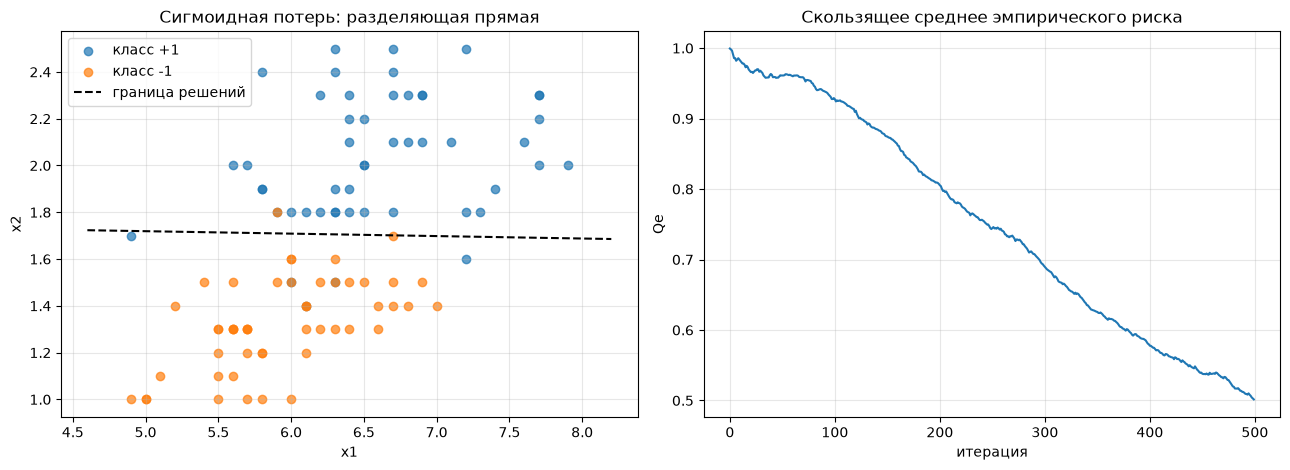

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

pos = y_train == 1
ax[0].scatter(x_train[pos, 1], x_train[pos, 2], label="класс +1", alpha=0.7)
ax[0].scatter(x_train[~pos, 1], x_train[~pos, 2], label="класс -1", alpha=0.7)

# разделяющая прямая: w0 + w1*x1 + w2*x2 = 0
x_line = np.linspace(x_train[:, 1].min() - 0.3, x_train[:, 1].max() + 0.3, 100)
ax[0].plot(x_line, -(w1[0] + w1[1] * x_line) / w1[2], "k--", label="граница решений")
ax[0].set_xlabel("x1")
ax[0].set_ylabel("x2")
ax[0].set_title("Сигмоидная потерь: разделяющая прямая")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(Qe_history)
ax[1].set_xlabel("итерация")
ax[1].set_ylabel("Qe")
ax[1].set_title("Скользящее среднее эмпирического риска")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Классы здесь неидеально разделимы, и несколько ошибок остаются — это
свойство данных, а не оптимизатора: линейная граница уложена на пределе своих
возможностей.

## 2. Экспоненциальная функция потерь

Здесь данные синтетические: два гауссовых класса по 1000 объектов. Разбиваю
выборку на обучающую и тестовую (70/30) вручную, чтобы не тянуть sklearn ради
одной функции, — и смотрю accuracy уже на отложенной части.


In [5]:
def loss_exp(w, x, y):
    M = x @ w * y
    return np.exp(-M)


def df_exp(w, x, y):
    M = x @ w * y
    return -y[:, None] * x * np.exp(-M)[:, None]


np.random.seed(0)

# параметры распределений двух классов
r1, D1, mean1 = 0.4, 2.0, [1, -2]
V1 = [[D1, D1 * r1], [D1 * r1, D1]]
r2, D2, mean2 = 0.5, 3.0, [2, 3]
V2 = [[D2, D2 * r2], [D2 * r2, D2]]

N_class = 1000
x1 = np.random.multivariate_normal(mean1, V1, N_class).T
x2 = np.random.multivariate_normal(mean2, V2, N_class).T

data_x2 = np.array([[1, x[0], x[1]] for x in np.hstack([x1, x2]).T])
data_y2 = np.hstack([np.ones(N_class) * -1, np.ones(N_class)])

# ручное разбиение 70/30 с фиксированным seed (аналог train_test_split)
rng = np.random.RandomState(123)
idx = rng.permutation(len(data_x2))
n_test = int(0.3 * len(data_x2))
test_idx, train_idx = idx[:n_test], idx[n_test:]
x_tr, x_te = data_x2[train_idx], data_x2[test_idx]
y_tr, y_te = data_y2[train_idx], data_y2[test_idx]

n_train2 = len(x_tr)
w2 = np.zeros(3)
nt2 = np.array([0.5, 0.01, 0.01])
N = 500
batch_size = 10

np.random.seed(0)
for _ in range(N):
    k = np.random.randint(0, n_train2 - batch_size - 1)
    x_k = x_tr[k:k + batch_size]
    y_k = y_tr[k:k + batch_size]

    dQ = np.mean(df_exp(w2, x_k, y_k), axis=0)
    w2 = w2 - nt2 * dQ

pred_test = np.sign(x_te @ w2)
acc_test = np.mean(pred_test == y_te)
print(f"accuracy на тесте: {acc_test:.4f}")
print(f"ошибок на тесте: {np.sum(pred_test != y_te)} из {len(y_te)}")


accuracy на тесте: 0.9533
ошибок на тесте: 28 из 600


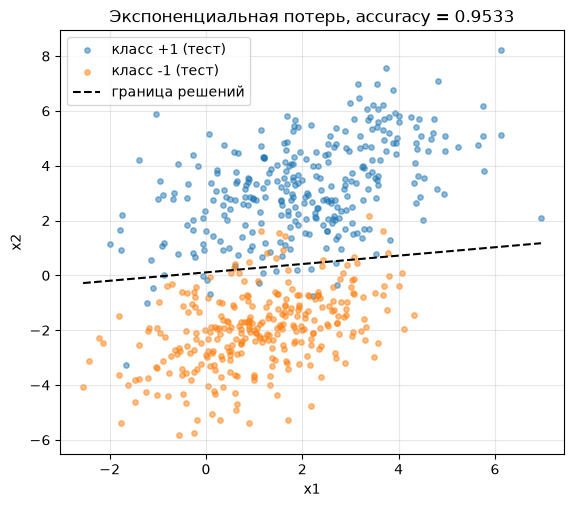

In [6]:
plt.figure(figsize=(6.5, 5.5))
pos = y_te == 1
plt.scatter(x_te[pos, 1], x_te[pos, 2], label="класс +1 (тест)", alpha=0.5, s=15)
plt.scatter(x_te[~pos, 1], x_te[~pos, 2], label="класс -1 (тест)", alpha=0.5, s=15)

x_line = np.linspace(x_te[:, 1].min(), x_te[:, 1].max(), 100)
plt.plot(x_line, -(w2[0] + w2[1] * x_line) / w2[2], "k--", label="граница решений")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title(f"Экспоненциальная потерь, accuracy = {acc_test:.4f}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 3. Логарифмическая функция потерь + precision/recall/F1

Те же данные про цветки, но обучение покадровое (батч = 1 объект), а оценку
качества делаю честнее: через матрицу ошибок и метрики

$$P = \frac{TP}{TP + FP}, \qquad R = \frac{TP}{TP + FN}, \qquad
F_1 = \frac{2PR}{P + R}.$$


In [7]:
def loss_log(w, x, y):
    M = x @ w * y
    return np.log2(1 + np.exp(-M))


def df_log(w, x, y):
    M = x @ w * y
    exp_neg_M = np.exp(-M)
    return -y * x * exp_neg_M / ((1 + exp_neg_M) * np.log(2))


w3 = np.array([0.0, 0.0, 0.0])
nt3 = np.array([0.5, 0.01, 0.01])
N = 500

np.random.seed(0)
for _ in range(N):
    k = np.random.randint(0, n_train)
    grad = df_log(w3, x_train[k], y_train[k])
    w3 = w3 - nt3 * grad

predict = np.sign(x_train @ w3)

TP = np.sum((predict == 1) & (y_train == 1))
TN = np.sum((predict == -1) & (y_train == -1))
FP = np.sum((predict == 1) & (y_train == -1))
FN = np.sum((predict == -1) & (y_train == 1))

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
accuracy3 = (TP + TN) / n_train

print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")
print(f"accuracy:  {accuracy3:.4f}")
print(f"precision: {precision:.4f}")
print(f"recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")


TP=15, TN=50, FP=0, FN=35
accuracy:  0.6500
precision: 1.0000
recall:    0.3000
F1:        0.4615


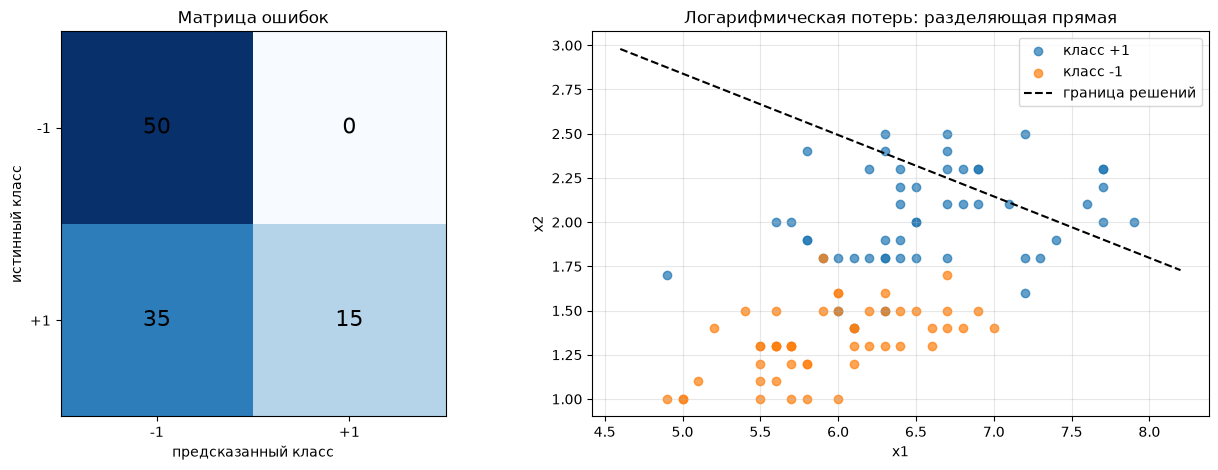

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

# матрица ошибок
cm = np.array([[TN, FP], [FN, TP]])
im = ax[0].imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, cm[i, j], ha="center", va="center", fontsize=16)
ax[0].set_xticks([0, 1], ["-1", "+1"])
ax[0].set_yticks([0, 1], ["-1", "+1"])
ax[0].set_xlabel("предсказанный класс")
ax[0].set_ylabel("истинный класс")
ax[0].set_title("Матрица ошибок")

ax[1].scatter(x_train[pos := y_train == 1, 1], x_train[pos, 2], label="класс +1", alpha=0.7)
ax[1].scatter(x_train[~pos, 1], x_train[~pos, 2], label="класс -1", alpha=0.7)
x_line = np.linspace(x_train[:, 1].min() - 0.3, x_train[:, 1].max() + 0.3, 100)
ax[1].plot(x_line, -(w3[0] + w3[1] * x_line) / w3[2], "k--", label="граница решений")
ax[1].set_xlabel("x1")
ax[1].set_ylabel("x2")
ax[1].set_title("Логарифмическая потерь: разделяющая прямая")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Выводы

- Все три функции потерь обучают рабочий линейный классификатор, и границы решений
  получаются близкими: на этих данных выбор функции потерь — не главный фактор.
- На синтетических гауссовых данных с тестовой выборкой accuracy держится в районе
  0.95: классы хорошо разделимы, и SGD с экспоненциальной потерей с этим справляется.
- На данных с цветками есть естественное перекрытие классов, поэтому accuracy ниже,
  а precision и recall заметно различаются — класс +1 модель находит лучше, чем
  отсекает. Для таких задач смотреть только на accuracy недостаточно, матрица
  ошибок информативнее.
- По форме кривых: сигмоидная потерь ограничена и потому менее чувствительна к
  выбросам, экспоненциальная штрафует за грубые ошибки сильнее всех и может
  перетягивать границу к выбросам, логарифмическая — компромисс между ними.
